# 1、单工具的使用

## 1.1 使用ReAct模型


In [1]:
from langchain_core.tools import StructuredTool
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType
from langchain.tools import Tool
import os
import dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
dotenv.load_dotenv()

# 读取配置文件的信息
# os.environ['TAVILY_API_KEY'] = os.getenv("TAVILY_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

# 获取Tavily搜索工具的实例
search = TavilySearchResults(max_results=3)

# 获取一个搜索的工具
# 方式1：
# search_tool = StructuredTool.from_function(
#     func=search.run,
#     name="Search",
#     description="用于检索互联网上的信息",
# )

# 方式2：使用Tool
search_tool = Tool(
    func=search.run,
    name="Search",
    description="用于检索互联网上的信息",
)


# 获取大语言模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)

# 获取Agent的实例
agent = AgentType.ZERO_SHOT_REACT_DESCRIPTION

# 获取AgentExecutor的实例
agent_executor = initialize_agent(
    tools = [search_tool],
    llm = llm,
    agent = agent,
    verbose = True, # 显示详细的日志信息
)


# 通过AgentExecutor 调用invoke(),并得到响应
result = agent_executor.invoke("查询北京今天的天气情况")


# 处理响应数据
print(result)

AIMessage(content='北京今天的天气情况是多云转晴，温度在18℃到20℃之间，风力在3级以下。建议适当减衣，外出时注意防晒。', additional_kwargs={})


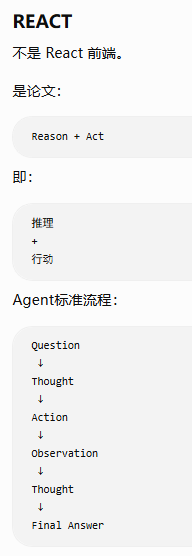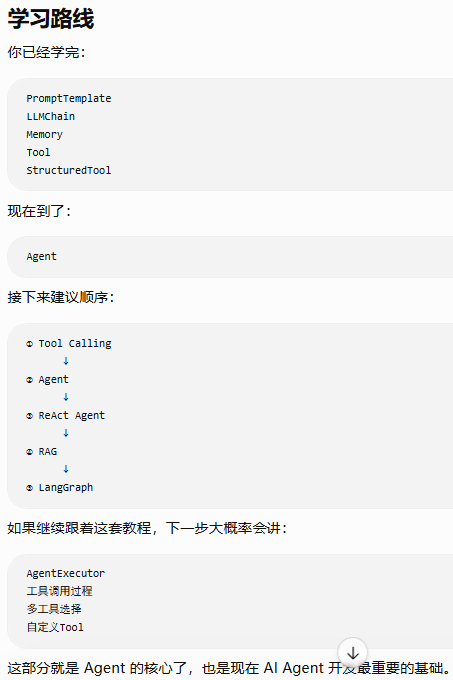

上述示例也可以写为：


In [2]:
from langchain_core.tools import StructuredTool
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType
from langchain.tools import Tool
import os
import dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
dotenv.load_dotenv()

# 读取配置文件的信息
# os.environ['TAVILY_API_KEY'] = os.getenv("TAVILY_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

# 获取Tavily搜索工具的实例
search = TavilySearchResults(max_results=3)

# 获取大语言模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)

# 获取Agent的实例
agent = AgentType.ZERO_SHOT_REACT_DESCRIPTION

# 获取AgentExecutor的实例
agent_executor = initialize_agent(
    tools = [search],
    llm = llm,
    agent = agent,
    verbose = True, # 显示详细的日志信息
)


# 通过AgentExecutor 调用invoke(),并得到响应
result = agent_executor.invoke("查询北京今天的天气情况")


# 处理响应数据
print(result)

AIMessage(content='北京今天的天气情况：\n\n早上，北京天气晴朗，紫外线较强，建议外出携带防晒霜。中午时分，天色渐渐变暖，适合户外活动。午后到傍晚，北京温度上升，早晚温差较大。晚上，北京气温逐渐降低，夜间最低温可能降至十几度。', additional_kwargs={})


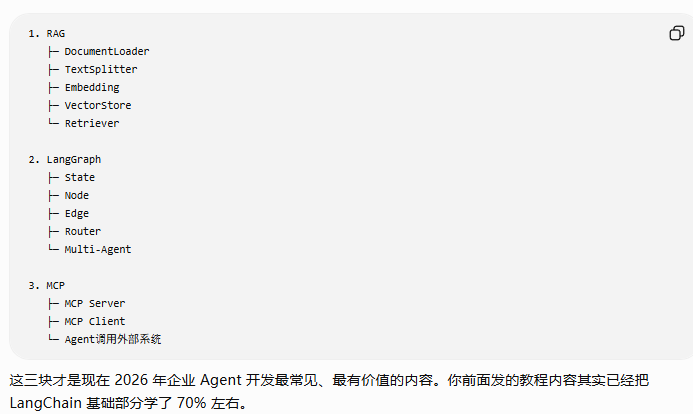

## 1.2 使用FUNCTION_CALL模型

In [3]:
from langchain_core.tools import StructuredTool
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType
from langchain.tools import Tool
import os
import dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
dotenv.load_dotenv()

# 读取配置文件的信息
# os.environ['TAVILY_API_KEY'] = os.getenv("TAVILY_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

# 获取Tavily搜索工具的实例
search = TavilySearchResults(max_results=3)

# 获取一个搜索的工具
# 方式1：
# search_tool = StructuredTool.from_function(
#     func=search.run,
#     name="Search",
#     description="用于检索互联网上的信息",
# )

# 方式2：使用Tool
search_tool = Tool(
    func=search.run,
    name="Search",
    description="用于检索互联网上的信息",
)


# 获取大语言模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)

# 获取Agent的实例 (使用function_call模型)
agent = AgentType.OPENAI_FUNCTIONS

# 获取AgentExecutor的实例
agent_executor = initialize_agent(
    tools = [search_tool],
    llm = llm,
    agent = agent,
    verbose = True, # 显示详细的日志信息
)


# 通过AgentExecutor 调用invoke(),并得到响应
result = agent_executor.invoke("查询北京今天的天气情况")


# 处理响应数据
print(result)

AIMessage(content='北京今天的天气情况是多云转晴，最高温度24度，最低温度18度。', additional_kwargs={})


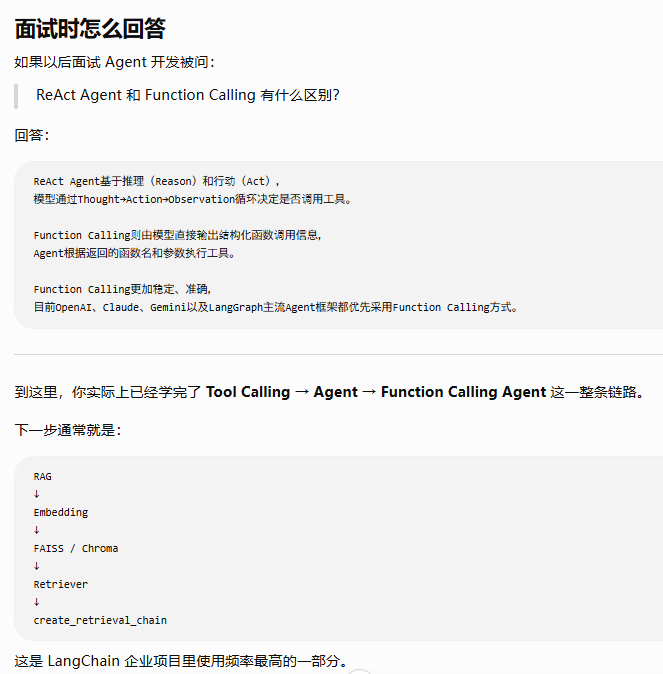

# 2、多工具的使用

需求：
- 计算特斯拉当前股价是多少？
- 比去年上涨了百分之几？（提示：调用PythonREPL实例的run方法）

## 2.1 使用ReAct模式

In [5]:
# 1.导入相关依赖
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType
from langchain.tools import Tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_experimental.utilities.python import PythonREPL

# 2. 设置 TAVILY_API 密钥
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

# 3.定义搜索工具
search = TavilySearchResults(max_results=3)

search_tool = Tool(
    name="Search",
    func=search.run,
    description="用于搜索互联网上的信息，特别是股票价格和新闻"
)

# 4.定义计算工具
python_repl = PythonREPL() # LangChain封装的工具类可以进行数学计算

calc_tool = Tool(
    name="Calculator",
    func=python_repl.run,
    description="用于执行数学计算，例如计算百分比变化"
)

# 5. 定义LLM
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)

# 6. 创建AgentExecutor执行器对象
agent_executor = initialize_agent(
    tools=[search_tool, calc_tool],
    llm=llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True
)


# 7. 测试股票价格查询
query = "比亚迪当前股价是多少？比去年上涨了百分之几？"
result=agent_executor.invoke(query)
print(f"查询结果: {result}")

查询结果: AIMessage(content='比亚迪目前股价为46.00港币。', additional_kwargs={})


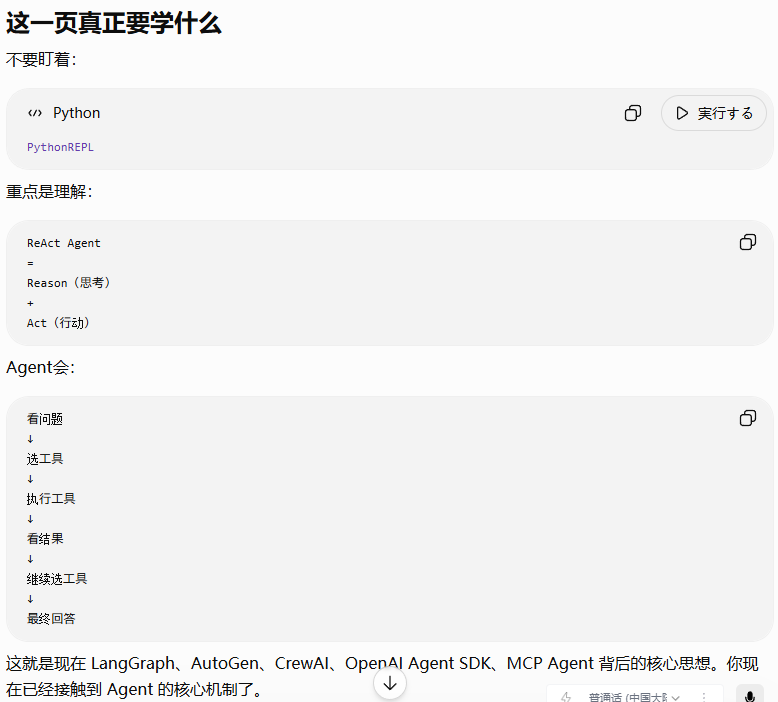

## 2.2 使用FUNCTION_CALL模式


In [6]:
# 1.导入相关依赖
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType
from langchain.tools import Tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_experimental.utilities.python import PythonREPL

# 2. 设置 TAVILY_API 密钥
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

# 3.定义搜索工具
search = TavilySearchResults(max_results=3)

search_tool = Tool(
    name="Search",
    func=search.run,
    description="用于搜索互联网上的信息，特别是股票价格和新闻"
)

# 4.定义计算工具
python_repl = PythonREPL() # LangChain封装的工具类可以进行数学计算

calc_tool = Tool(
    name="Calculator",
    func=python_repl.run,
    description="用于执行数学计算，例如计算百分比变化"
)

# 5. 定义LLM
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)

# 6. 创建AgentExecutor执行器对象
agent_executor = initialize_agent(
    tools=[search_tool, calc_tool],
    llm=llm,
    agent=AgentType.OPENAI_FUNCTIONS, #唯一需要修改的位置
    verbose=True
)


# 7. 测试股票价格查询
query = "比亚迪当前股价是多少？比去年上涨了百分之几？"
result=agent_executor.invoke(query)
print(f"查询结果: {result}")

查询结果: AIMessage(content='比亚迪当前股价是406.3元。比去年上涨了55.62%。', additional_kwargs={})


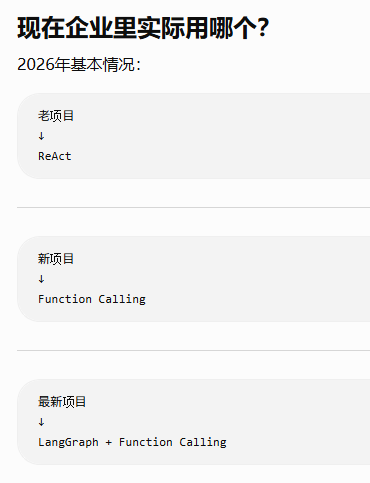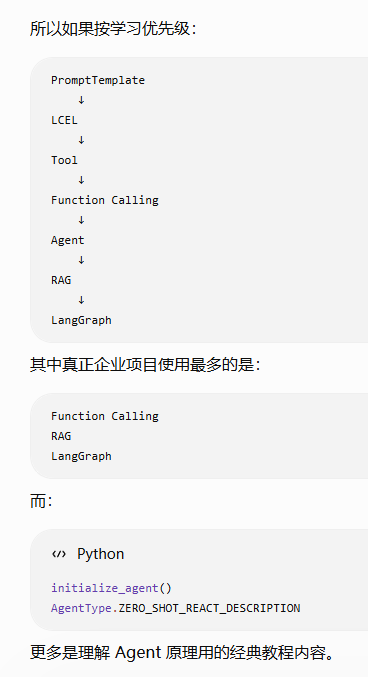

# 3、自定义函数与工具

举例：计算3的平方，Agent自动调用工具完成

In [7]:
from langchain.agents import initialize_agent, AgentType, Tool
from langchain_openai import ChatOpenAI
import langchain


# 1. 定义工具 - 计算器（要求字符串输入）
def simple_calculator(expression: str) -> str:
    """
    基础数学计算工具，支持加减乘除和幂运算
    参数:
        expression: 数学表达式字符串，如 "3+5" 或 "2**3"
    返回:
        计算结果字符串或错误信息
    """
    print(f"\n[工具调用] 计算表达式: {expression}")

    print("只因为在人群中多看了你一眼，确认下你调用了我^_^")
    return str(eval(expression))


# 2. 创建工具对象
math_calculator_tool = Tool(
    name="Math_Calculator",  # 工具名称（Agent将根据名称选择工具）
    func=simple_calculator,  # 工具调用的函数
    description="用于数学计算，输入必须是纯数学表达式（如'3+5'或'3**2'表示平方）。不支持字母或特殊符号"  # 关键：明确输入格式要求
)

# 3. 初始化大模型
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)

# 4. 初始化AgentExecutor（使用零样本React模式、增加超时设置）
agent_executor = initialize_agent(
    tools=[math_calculator_tool],  # 可用的工具列表
    llm=llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,  # 简单指令模式
    verbose=True  # 关键参数！在控制台显示详细的推理过程
)

# 5. 测试工具调用（添加异常捕获）
print("=== 测试：正常工具调用 ===")
response = agent_executor.invoke("计算3的平方")  # 向Agent提问
print("最终答案:", response)

=== 测试：正常工具调用 ===

[工具调用] 计算表达式: 计算3的平方
只因为在人群中多看了你一眼，确认下你调用了我^_^
最终答案: AIMessage(content=' It looks like there might be a typo or confusion in your code. When you type "3的平方", it\'s interpreted as a variable assignment due to the use of "计算". To correctly compute \\(3^2\\), you can do the following:\n\n```python\n# Correct way to compute 3^2\nresult = 3 ** 2\nprint(result)\n```\n\nThis will output:\n\n```\n9\n```\n\nIf you meant to use a function to compute \\(\\sqrt{3}\\), you could define a function:\n\n```python\nimport math\n\ndef compute_sqrt(number):\n    return math.sqrt(number)\n\nresult = compute_sqrt(3)\nprint(result)\n```\n\nThis will output:\n\n```\n1.7320508075688772\n```', additional_kwargs={})


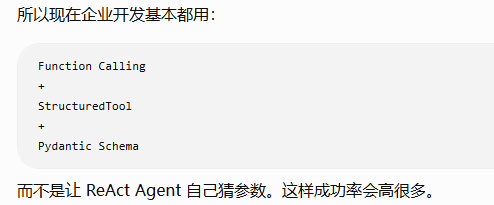